## Init stuff

In [1]:
import os

if os.getcwd() == '/home/dcor/niskhizov':
    os.chdir('//home/dcor/niskhizov/PhysicalAdverserialProj/')
    on_remote = True
else:
    on_remote = False
    

In [2]:
from comet_ml import start, ExistingExperiment
from comet_ml.integration.pytorch import log_model

experiment = start(
  api_key="Bg5eubpUjdi2CCiiA5OSoltfw",
  project_name="physicaladvproj",
  workspace="dannynis"
)

# Get the experiment ID, end it, and re-attach to ensure code capture
experiment_key = experiment.get_key()
print(f"Experiment key: {experiment_key}")


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/dannynis/physicaladvproj/64b6782df4564a6e8e073cd15c694b4d



Experiment key: 64b6782df4564a6e8e073cd15c694b4d


COMET INFO: Couldn't find a Git repository in '/home/dcor/niskhizov/PhysicalAdverserialProj' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


In [3]:
%matplotlib inline

In [5]:

import torch
import torch.nn as nn
import torchvision.models as models

import glob
import tqdm
import matplotlib.pyplot as plt
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import time
from tqdm import tqdm
import copy
from IPython.display import display, Image, clear_output
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import datetime


import cv2
import os
import glob


import kornia
import tqdm

import torchvision

tt = torchvision.transforms.ToTensor()

import cv2
import cv2.aruco as aruco
import numpy as np

from consts import border_size, displayed_aruco_code, marker_size, latent_size, latent_batch_size, hard_targets

# from classfier import *
# from classfier_clip import *
# from classfier_dino import *
from classfier import predict_raw, orig_clases, model, weights
from classfier import predict_raw as predict_raw_dev
from classfier import predict_raw as predict_raw_test
from functools import partial

from classfier_test import model as model_test
from classfier import model as model_dev

model_name = model if type(model) == str else model.__class__.__name__

print(f'For training using classfier_dev model: {model.__class__.__name__}  ')
print('###############################')
print(f'For Dev using classfier_dev model: {model_dev.__class__.__name__}  ')
print('###############################')
print(f'For Test using classfier_test model: {model_test.__class__.__name__}  ')




if 'weight_dict' in predict_raw.__code__.co_varnames:

    classfiers_weights_dict = {
    'inception': 0.25,
    'resnet': 0.25,
    'vgg': 0.25,
    'vit': 0.25,
    'dino': 0.0}
    
    experiment.log_parameters(classfiers_weights_dict)
    predict_raw = partial(predict_raw, weights_dict=classfiers_weights_dict)
# predict_raw_per_model = partial(predict_raw_per_model, weights_dict=classfiers_weights_dict)




import pickle as pkl


# orig_clases = torch.tensor([999,700, 419]).cuda() # apple
# orig_clases = torch.tensor([948,956]).cuda()

print( '#################################')
print( f'ORIG CLASES {orig_clases}')
print( f'HARD TARGETS: {hard_targets}')
photometric_calibrations_dir = './photometric_calibrations'
# load latest photometric calibration by time
photometric_calibration_files = glob.glob(os.path.join(photometric_calibrations_dir, 'photometric_calibration_*.pkl'))
photometric_calibration_files.sort(key=os.path.getmtime, reverse=True)
photometric_calibration_path = photometric_calibration_files[0]
print(f'############## Loading photometric calibration data from {photometric_calibration_path} ##############')

with open(photometric_calibration_path, "rb") as f:
    data = pkl.load(f)

height = data['height']
width = data['width']

resizer = torchvision.transforms.Resize((height, width))
device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Define parameters for ArUco marker detection
aruco_dict_type = cv2.aruco.DICT_4X4_50 # Change dictionary type if needed
marker_length = 0.05  # Marker length in meters (adjust as needed)
aruco_dict = cv2.aruco.getPredefinedDictionary(aruco_dict_type)

marker_id = displayed_aruco_code
marker_size = marker_size  # Size in pixels
marker_image = cv2.aruco.generateImageMarker(aruco_dict, marker_id, marker_size)


aruco_dict = aruco.getPredefinedDictionary(aruco_dict_type)
parameters = aruco.DetectorParameters()

# Detect ArUco markers
detector = aruco.ArucoDetector(aruco_dict, parameters)


from diffusers import StableDiffusionPipeline
import torch

# Load stable diffusion model


def decode_latents_grad(latents):
    # latents = F.interpolate(latents, (64, 64), mode='bilinear', align_corners=False)
    latents = 1 / 0.18215 * latents

    imgs = vae.decode(latents).sample

    imgs = (imgs / 2 + 0.5).clamp(0, 1)

    return imgs

def decode_latents(latents):
    # latents = F.interpolate(latents, (64, 64), mode='bilinear', align_corners=False)
    with torch.no_grad():
        with torch.amp.autocast(device):
            latents = 1 / 0.18215 * latents

            with torch.no_grad():
                imgs = vae.decode(latents).sample

            imgs = (imgs / 2 + 0.5).clamp(0, 1)

    return imgs

def encode_imgs(imgs):
    # imgs: [B, 3, H, W]
    with torch.no_grad():
        with torch.amp.autocast(device):
            imgs = 2 * imgs - 1

            posterior = vae.encode(imgs).latent_dist
            latents = posterior.sample() * 0.18215

    return latents



class framesDataset(Dataset):
    def __init__(self, frames, Hs):
        self.frames = frames
        self.Hs = Hs

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        frame = self.frames[idx]
        H = self.Hs[idx]

        # Convert to tensor and normalize
        frame_tensor = tt(frame)

        return frame_tensor, H.astype(np.float32)
    





def warp(decoded_latents,H_t):
    dst_img_shape = valid_frames[0].shape[:2]
    warped_imgs = []
    for decoded_latent in decoded_latents:
        img = decoded_latent.unsqueeze(0).float().repeat(H_t.shape[0], 1, 1, 1)
        w=  kornia.geometry.transform.warp_perspective(img, H_t, dst_img_shape)
        warped_imgs.append(w)
    return torch.stack(warped_imgs, dim=0)#.squeeze(1)


vae = None
valid_frames = None

os.makedirs('./results', exist_ok=True)
curr_without_sec = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
curr_without_sec = curr_without_sec.replace(" ", "_").replace(":", "_")




pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4")

vae =  pipe.vae.to(device).eval()
# compile vae for faster execution
# vae = torch.compile(pipe.vae.to(device).eval())


try:
    first_class_idx = orig_clases[0].item()
    first_class_name = weights.meta['categories'][first_class_idx]
    experiment_name = f"{model_name}_{curr_without_sec}_{first_class_name}"
    experiment.set_name(experiment_name)
    print(f"Experiment name set to: {experiment_name}")
except Exception as e:
    print(f"Could not set experiment name: {e}")

For training using classfier_dev model: Inception3  
###############################
For Dev using classfier_dev model: Inception3  
###############################
For Test using classfier_test model: EfficientNet  
#################################
ORIG CLASES tensor([700, 999, 530], device='cuda:0')
HARD TARGETS: {1: 'goldfish, Carassius auratus', 7: 'cock', 21: 'kite', 207: 'golden retriever', 340: 'zebra', 745: 'projector', 779: 'school bus', 846: 'table lamp', 947: 'mushroom', 950: 'orange'}
############## Loading photometric calibration data from ./photometric_calibrations/photometric_calibration_20251230_190959.pkl ##############


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Experiment name set to: Inception3_2026-01-05_21_21_paper towel


In [8]:
from consts import border_size, displayed_aruco_code, latent_size, latent_batch_size
print(f'Using border size {border_size} for ArUco detection')
print(f'Using latent size {latent_size}x{latent_size}')
print(f'Using latent batch size {latent_batch_size}')
# border_glow_margin = 5

Using border size 2 for ArUco detection
Using latent size 16x16
Using latent batch size 30


In [9]:
def find_border_drop_point(gray, c):
    sub = np.subtract
    add = np.add
    borders_drop_points = []
    for idx,operators in enumerate(([sub,sub],[add,sub],[add,add],[sub,add])):

        margin = 1
        a,b = int(c[idx][0]), int(c[idx][1])
        diag_idxs = np.arange(5)

        nca = operators[0](a, diag_idxs)
        ncb = operators[1](b, diag_idxs)
        nc = np.stack([nca, ncb], axis=1)

        diag_line_vals = gray[nc[:, 1], nc[:, 0]].astype(np.float32)
        diag_line_vals_diff = np.diff(diag_line_vals)
        if np.all(diag_line_vals_diff >= 0):
            # did not find border drop point, use the first point
            borders_drop_points.append((nca[0], ncb[0]))
            continue
        diag_line_vals_diff_first_neg = min(np.where(diag_line_vals_diff < 0)[0][0] + margin, len(diag_line_vals_diff)-1)
        new_a = nca[diag_line_vals_diff_first_neg]
        new_b = ncb[diag_line_vals_diff_first_neg]
        borders_drop_points.append((new_a, new_b))

        
    return np.array(borders_drop_points)


caps_dir = 'captures_frames_multiview'
ls = os.listdir(f'./{caps_dir}')
captures = [f for f in ls if f.startswith('captures_frames_multiview_') ]
captures = sorted(captures, key=lambda x: int(x.split('_')[-1]))
cap_dir = f'./{caps_dir}/{captures[-1]}'#f'captures_frames_multiview_{len(captures)-1}'

# cap_dir = f'./{caps_dir}/captures_frames_multiview_64'#{captures[-1]}'#f'captures_frames_multiview_{len(captures)-1}'
# # cap_dir = f'./{caps_dir}/captures_frames_multiview_{len(captures)-1}'
# # cap_dir = f'./{caps_dir}/captures_frames_multiview_52'#{captures[-1]}'#f'captures_frames_multiview_{len(captures)-1}'


print('using capture dir', cap_dir)


valid_frame_paths = glob.glob(f'{cap_dir}/*.png')

valid_frames = []

Hs = []

# orig_img_corners = np.array([[0,0],[l_size_w,0],[l_size_w,l_size_h],[0,l_size_h]], dtype=np.float32)
orig_img_corners = np.array([[border_size,border_size],[width-border_size,border_size],[width-border_size,height-border_size],[border_size,height-border_size]], dtype=np.float32)


found_aruco_count = 0
outlier_clases = []
for path in tqdm.tqdm_notebook(valid_frame_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    corners, ids, _ = detector.detectMarkers(gray)

    if ids is None:
        continue
    
    found_aruco_count += 1

    with torch.no_grad():
        # pr = resnet_predict_raw(tt(img).cuda().unsqueeze(0))
        # print(model)
        pr = predict_raw(tt(img).cuda().unsqueeze(0))

        pres_img = img.copy()
        if ids is not None:
            aruco.drawDetectedMarkers(pres_img, corners, ids)
        cat = weights.meta["categories"][pr.argmax(1)]
        if not on_remote:
            cv2.putText(pres_img, f'pred: {cat} {pr.max().item():.2f}', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
            cv2.imshow('pres', cv2.cvtColor(pres_img,cv2.COLOR_RGB2BGR))
            cv2.waitKey(1)
        

    if ids is not None and displayed_aruco_code in ids and pr.argmax(1) in orig_clases:
        
        displayed_aruco_code_index = np.where(ids.flatten() == displayed_aruco_code)[0][0]
        corners = corners[displayed_aruco_code_index][0]
        
        unbordred_corners = find_border_drop_point(gray, corners)

        # unbordred_corners = np.array([[c[0][0]-per_corner_glow_margin, c[0][1]-border_glow_margin],
        #                     [c[1][0]+border_glow_margin, c[1][1]-border_glow_margin],
        #                     [c[2][0]+border_glow_margin, c[2][1]+border_glow_margin],
        #                     [c[3][0]-border_glow_margin, c[3][1]+border_glow_margin]])

        # dst_pts = unbordred_corners
        H, _ = cv2.findHomography(orig_img_corners, unbordred_corners, cv2.RANSAC)

        Hs.append(H)
        valid_frames.append(img)
        

    else :
        outlier_clases.append(pr.argmax(1))
cv2.destroyAllWindows()
print(f"Detected ArUco markers in {found_aruco_count} out of {len(valid_frame_paths)} frames.")
print(f"Found {len(valid_frames)} valid frames with ArUco markers and original classes.")

# print('DEBUG training')
# valid_frames = [valid_frames[0]]*10
# Hs = [Hs[0]]*10

# Use ALL valid frames instead of limiting to 10
# print(f"Using ALL {len(valid_frames)} frames for training.")

random_idx = np.random.permutation(min(len(valid_frames), 1000000))
valid_frames = [valid_frames[i] for i in random_idx]
Hs = [Hs[i] for i in random_idx]

print(f"Total valid frames to be used for training: {len(valid_frames)}")

# No need to subset - use all valid frames
# valid_frames and Hs already contain all valid frames


ds = framesDataset(valid_frames, Hs)


print('creating dataloader')
# Calculate split sizes that sum to dataset length
total_len = len(ds)
train_len = int(total_len * 0.8)
val_len = int(total_len * 0.1)
test_len = total_len - train_len - val_len  # Ensure exact sum

print(f"Dataset split: train={train_len}, val={val_len}, test={test_len}, total={total_len}")
train,val,test = torch.utils.data.random_split(ds, [train_len, val_len, test_len])
# train,val,test = ds,ds,ds
train_loader = DataLoader(train, batch_size=1, shuffle=True)#, num_workers=2, persistent_workers=True)
val_loader = DataLoader(val, batch_size=len(val), shuffle=False)#), num_workers=2, persistent_workers=True)
test_loader = DataLoader(test, batch_size=len(test), shuffle=False)#, num_workers=2, persistent_workers=True)

print('dataloader created')
    
# latent.requires_grad = True



def random_blur(img):
    k_size = np.random.choice([3,5,7])
    sigma = np.random.uniform(0.1, 1.0)
    return T.GaussianBlur(kernel_size=k_size, sigma=(sigma, sigma))(img)

# Define augmentation functions with Gaussian blur to simulate camera/projector defocus
jitter = T.Compose([
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    random_blur
])

jitter_total_photo = T.Compose([
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))  # Slight blur for unfocused camera/projector
])

jitter_with_hue = T.Compose([
    T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),
    T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.0))  # More aggressive blur
])

augmentor_model = data['augmentor'].to(device).eval()
# augmentor_model = torch.compile(augmentor_model)
# mapper = lambda x: jitter(x)

using capture dir ./captures_frames_multiview/captures_frames_multiview_122


/tmp/ipykernel_669348/1895824340.py:56: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for path in tqdm.tqdm_notebook(valid_frame_paths):


  0%|          | 0/216 [00:00<?, ?it/s]

Detected ArUco markers in 201 out of 216 frames.
Found 52 valid frames with ArUco markers and original classes.
Total valid frames to be used for training: 52
creating dataloader
Dataset split: train=41, val=5, test=6, total=52
dataloader created


In [10]:
categories = weights.meta['categories']

In [11]:
categories[530]

'digital clock'

In [12]:
categories.index('paper towel')

700

In [13]:
torch.stack(outlier_clases).unique(return_counts=True)

(tensor([412, 487, 508, 530, 543, 605, 620, 626, 632, 662, 700, 761, 804, 844,
         877, 999], device='cuda:0'),
 tensor([18,  1, 10, 72,  1,  5,  2,  1,  8,  1,  2,  1,  2, 19,  4,  2],
        device='cuda:0'))

In [14]:
# No need to load single frame - we'll iterate through all frames
print(f"Dataset contains {len(train_loader)} training batches")
print(f"Total training frames: {len(train_loader.dataset)}")
print(f"Validation frames: {len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0}")
print(f"Test frames: {len(test_loader.dataset) if len(test_loader.dataset) > 0 else 0}")
print("Ready to process ALL frames during training!")

Dataset contains 41 training batches
Total training frames: 41
Validation frames: 5
Test frames: 6
Ready to process ALL frames during training!


In [15]:
sample_frame, sample_H = next(iter(train_loader))


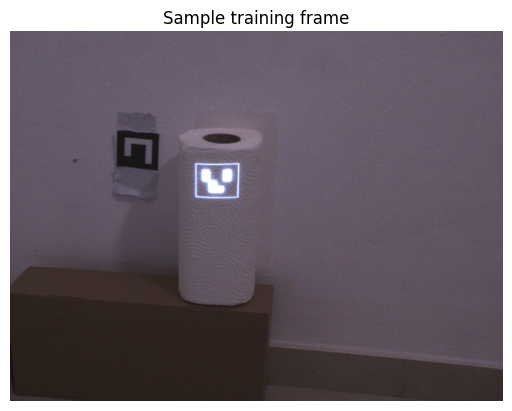

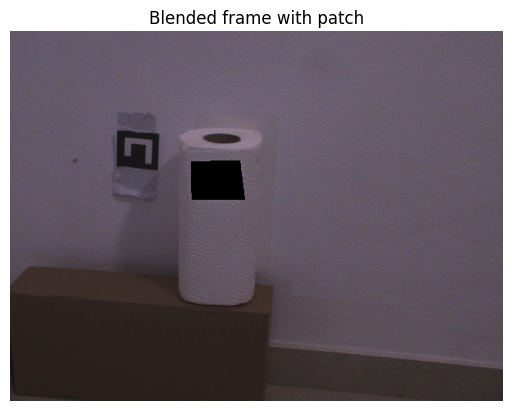

In [16]:
# Display a sample frame from the dataset
sample_frame, sample_H = next(iter(train_loader))
plt.imshow(sample_frame[0].permute(1,2,0).cpu().numpy())
plt.title("Sample training frame")
plt.axis('off')
plt.show()

patch = torch.zeros((1, 3, height, width), device=device).to(device)

# patch = torch.zeros((1, 3, int(height * 1.5) , int(width * 1.5) ), device=device).to(device)
H = sample_H.to(device)
frame = sample_frame.to(device)
w_mask = warp(patch * 0 + 1, H)
w_patch = warp(patch, H)

# Full replacement for maximum effect
blend_ratio = 1.0
blended_frames = ((w_mask != 0) * -blend_ratio + 1) * frame + w_patch * blend_ratio

plt.imshow(blended_frames[0,0,...].permute(1,2,0).cpu().numpy())
plt.title("Blended frame with patch")
plt.axis('off')
plt.show()

In [ ]:
hard_targets = {idx:val for idx,val in enumerate(weights.meta['categories'])}
target_class_indices = torch.tensor(list(hard_targets.keys()), device=device)
target_class_names = list(hard_targets.values())
single_tensor_to_optimizer = torch.randn((height, width))
single_tensor_to_optimizer.requires_grad = True
single_optimizer = torch.optim.Adam([single_tensor_to_optimizer])


In [ ]:
single_tensor_to_optimizer = torch.randn((height, width))
single_tensor_to_optimizer.requires_grad = True
single_optimizer = torch.optim.Adam([single_tensor_to_optimizer])

for i in range(1000):
    


In [ ]:
# Load successful latent if available, otherwise reinitialize
print("Attempting to load successful latent or reinitializing...")

# ==================== ATTACK MODE CONFIGURATION ====================
# Set targeted = True for TARGETED attack (learn patches to misclassify TO specific classes)
# Set targeted = False for UNTARGETED attack (learn patches to misclassify AWAY from original class)
targeted = True  # <-- CHANGE THIS TO SWITCH BETWEEN TARGETED AND UNTARGETED ATTACKS

# Set targeted_sequential = True to optimize one target class at a time (sequential mode)
# Set targeted_sequential = False to optimize all target classes in parallel (batch mode)
targeted_sequential = True  # <-- Only applies when targeted = True

# ==================== DEBUG: SINGLE TARGET MODE ====================
# Override hard_targets to focus on just goldfish (class 1) for debugging
# Once this works, comment out this line to use all targets from consts.py
DEBUG_SINGLE_TARGET = True  # Set to False to use all targets from consts.py
if DEBUG_SINGLE_TARGET:
    # hard_targets = {1: 'goldfish, Carassius auratus'}
    # print("⚠️ DEBUG MODE: Only targeting goldfish (class 1)")
    hard_targets = {idx:val for idx,val in enumerate(weights.meta['categories'])}
# ===================================================================
targeted_sequential = True  # <-- Only applies when targeted = True

# Determine batch size based on attack mode
if targeted:
    # For targeted attacks, we learn one patch per target class from hard_targets
    target_class_indices = torch.tensor(list(hard_targets.keys()), device=device)
    target_class_names = list(hard_targets.values())
    
    if targeted_sequential:
        # Sequential mode: we'll optimize one target class at a time
        # Use latent_batch_size patches per target for parallel optimization within each target
        targeted_latent_batch_size = latent_batch_size
        print(f"🎯 TARGETED SEQUENTIAL ATTACK MODE ENABLED")
        print(f"   Will optimize {len(hard_targets)} target classes ONE AT A TIME")
        print(f"   Using {targeted_latent_batch_size} patches in parallel per target class:")
        for idx, (cls_idx, cls_name) in enumerate(hard_targets.items()):
            print(f"   Target #{idx+1} -> Class {cls_idx}: {cls_name}")
        
        # Create storage for all optimized patches
        all_target_patches = {}
        all_target_latents = {}
    else:
        # Parallel mode: optimize all target classes together
        targeted_latent_batch_size = len(hard_targets)
        print(f"🎯 TARGETED PARALLEL ATTACK MODE ENABLED")
        print(f"   Learning {targeted_latent_batch_size} patches for target classes simultaneously:")
        for idx, (cls_idx, cls_name) in enumerate(hard_targets.items()):
            print(f"   Patch #{idx+1} -> Class {cls_idx}: {cls_name}")
    
    # Initialize latent batch with size = number of target classes (or 1 for sequential)
    latent_batch = torch.randn((targeted_latent_batch_size, 4, latent_size, latent_size), device=device) * 0.8
else:
    # For untargeted attacks, use the configured latent_batch_size from consts.py
    target_class_indices = None
    target_class_names = None
    print(f"🔄 UNTARGETED ATTACK MODE ENABLED")
    print(f"   Learning {latent_batch_size} patches to misclassify away from original classes")
    
    # Initialize latent batch with configured size
    latent_batch = torch.randn((latent_batch_size, 4, latent_size, latent_size), device=device) * 0.8

# latent_batch = torch.load('./results/full_latent_batch_epoch_33_2025-11-14_03_10.pt')
# print('!!! Loaded latent batch from file ./results/full_latent_batch_epoch_33_2025-11-14_03_10.pt !!!')
# print("Using fresh random initialization with larger variance")

latent_batch.requires_grad = True

# Use a more conservative optimizer with higher learning rate
latent_opt = torch.optim.Adam([latent_batch], lr=0.1)  # Higher LR, simpler optimizer
# add cosine annealing scheduler  after epoch 3


orig_clases_np = orig_clases.cpu().numpy()
print(f"Latent shape: {latent_batch.shape}")
print(f"Original classes to avoid: {orig_clases_np}")
if targeted:
    print(f"Target classes to achieve: {target_class_indices.cpu().numpy()}")
# print(f"Other classes available: {len(total_clases_without_orig)}")

# Test initial prediction
with torch.no_grad():
    test_patch = resizer(decode_latents(latent_batch).float())
    print(f"Generated patch shape: {test_patch.shape}")
    print("Initialization complete!")

In [ ]:

aug_weight = 0.4
# Training parameters
num_epochs = 100  # More epochs for better convergence
blend_ratio = 1.0  # Full replacement
best_loss = float('inf')
best_latent = None
best_success_rate = 0
success_count = 0
training_stopped = False  # Flag for early stopping when patch > 50%
aug_rate = None
to_rejuvenate = False
use_scheduler = False  # Enable learning rate scheduling for better convergence

# Scheduler configuration - use OneCycleLR for better training dynamics
scheduler_config = {
    'type': 'OneCycleLR',  # Options: 'OneCycleLR', 'StepLR', 'CosineAnnealingLR', None
    'max_lr': 0.15,       # Higher peak LR for faster initial exploration
    'pct_start': 0.1,     # Warmup for 10% of training
    'step_size': 50,      # For StepLR
    'gamma': 0.9,         # For StepLR
    'T_max': num_epochs,  # For CosineAnnealingLR
}

def create_scheduler(optimizer, config, total_steps):
    """Create a learning rate scheduler based on configuration.
    
    Args:
        optimizer: The optimizer to schedule
        config: Dictionary with scheduler configuration
        total_steps: Total number of training steps/epochs
        
    Returns:
        scheduler or None if disabled
    """
    if config is None or config.get('type') is None:
        print("📉 No scheduler - using constant learning rate")
        return None
    
    scheduler_type = config['type']
    
    if scheduler_type == 'OneCycleLR':
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=config.get('max_lr', 0.1),
            total_steps=total_steps,
            pct_start=config.get('pct_start', 0.0)
        )
        print(f"📈 Initialized OneCycleLR with max_lr={config.get('max_lr', 0.1)}, pct_start={config.get('pct_start', 0.0):.4f}")
    
    elif scheduler_type == 'StepLR':
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config.get('step_size', 50),
            gamma=config.get('gamma', 0.9)
        )
        print(f"📈 Initialized StepLR with step_size={config.get('step_size', 50)}, gamma={config.get('gamma', 0.9)}")
    
    elif scheduler_type == 'CosineAnnealingLR':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config.get('T_max', total_steps),
            eta_min=config.get('eta_min', 0.0001)
        )
        print(f"📈 Initialized CosineAnnealingLR with T_max={config.get('T_max', total_steps)}")
    
    else:
        print(f"⚠️ Unknown scheduler type: {scheduler_type}, using no scheduler")
        return None
    
    return scheduler

# Initialize scheduler (or None if disabled)
if use_scheduler:
    scheduler = create_scheduler(latent_opt, scheduler_config, num_epochs)
else:
    scheduler = None
    print("📉 Scheduler disabled - using constant learning rate")

# Helper to get current learning rate
def get_current_lr(optimizer, scheduler):
    if scheduler is not None:
        return scheduler.get_last_lr()[0]
    return optimizer.param_groups[0]['lr']

# Log parameters including attack mode
experiment.log_parameters({
    "aug_weight": aug_weight,
    "num_epochs": num_epochs,
    "blend_ratio": blend_ratio,
    "initial_lr": 0.1,
    "latent_batch_size": latent_batch.shape[0],
    "latent_size": latent_size,
    "model_name": model.__class__.__name__,
    "model_dev_name": model_dev.__class__.__name__,
    "model_test_name": model_test.__class__.__name__,
    "scheduler": scheduler_config.get('type') if use_scheduler else "None",
    "pct_start": scheduler_config.get('pct_start', 0.0),
    "to_rejuvenate": to_rejuvenate,
    "use_scheduler": use_scheduler,
    "targeted_attack": targeted,
    "targeted_sequential": targeted_sequential if targeted else False,
    "num_target_classes": len(hard_targets) if targeted else 0,
    "target_class_indices": list(hard_targets.keys()) if targeted else [],
})


In [ ]:
training_stopped = False

## Trainig

In [ ]:
# Robust adversarial attack working on ALL frames with augmentation training
print("Starting ROBUST adversarial attack on ALL frames in dataset...")
print("🔧 Augmentations enabled: jitter on patch, augmentor on patch, jitter_total_photo on final image")
print("This will make the patch robust against real-world variations!")

# ==================== ATTACK MODE CONFIGURATION ====================
# Set targeted = True for TARGETED attack (learn patches to misclassify TO specific classes)
# Set targeted = False for UNTARGETED attack (learn patches to misclassify AWAY from original class)
targeted = True  # <-- CHANGE THIS TO SWITCH BETWEEN TARGETED AND UNTARGETED ATTACKS

# Loss tracking
losses = []
success_rates = []

# For targeted attacks, we learn one patch per hard_target class (from consts.py)
# For untargeted attacks, we use the configured latent_batch_size
if targeted:
    # Extract target class indices from hard_targets dictionary
    target_class_indices = torch.tensor(list(hard_targets.keys()), device=device)
    target_class_names = list(hard_targets.values())
    num_patches = len(target_class_indices)
    print(f"🎯 TARGETED ATTACK MODE: Learning {num_patches} patches for {num_patches} target classes")
    for idx, (cls_idx, cls_name) in enumerate(hard_targets.items()):
        print(f"   Patch #{idx+1} -> Target class {cls_idx}: {cls_name}")
else:
    num_patches = latent_batch.shape[0]
    target_class_indices = None
    target_class_names = None
    print(f"🔄 UNTARGETED ATTACK MODE: Learning {num_patches} patches to misclassify away from original class")

# Per-patch performance tracking
# Better target class selection - classes that are visually very different from vehicles
# NOTE: These are only used for untargeted attacks. For targeted, we use hard_targets from consts.py
target_classes = torch.tensor([
#     # 1,    # tench (fish)
#     # 2,    # goldfish  
#     # 3,    # great white shark
#     # 4,    # tiger shark
#     # 50,   # American robin (bird)
#     # 285,  # Egyptian cat
#     # 281,  # tabby cat
#     # 805,  # soccer ball
#     # 999,  # toilet tissue
#     # 732,  # Polaroid camera (this worked before!)
    # 530,  # digital clock
#     # 575, # golf cart
#     # 627, # limousine
    
    
], device=device)
# target_classes = torch.tensor([x for x in range(1000) if x not in orig_clases.cpu().numpy()], device=device)
# target_classes = torch.tensor([], device=device)

if not targeted:
    print(f"Target classes (untargeted mode bonus): {[weights.meta['categories'][i] for i in target_classes.cpu().numpy()]}")
print(f"Training on {len(train_loader)} batches per epoch (ALL frames)")


augmentor = lambda x: augmentor_model(x).to(device) * aug_weight + x * (1-aug_weight)

In [ ]:
weights.meta['categories'].index('tennis ball')

In [ ]:
for x in weights.meta['categories']:
    if 'golf' in x:
        print(x)

In [ ]:
patch_history = []

In [ ]:
best_patch_idx = None
epoch = 0

In [ ]:
experiment.end()
print("Re-attaching to experiment...")
experiment = ExistingExperiment(
  api_key="Bg5eubpUjdi2CCiiA5OSoltfw",
  previous_experiment=experiment_key
)

In [ ]:
## training loop

# Sequential mode: iterate over each target class one at a time
if targeted and targeted_sequential:
    target_classes_list = list(hard_targets.items())
    print(f"\n{'='*60}")
    print(f"🎯 SEQUENTIAL TARGETED ATTACK - {len(target_classes_list)} targets")
    print(f"{'='*60}\n")
else:
    target_classes_list = [(None, None)]  # Single iteration for parallel/untargeted

for seq_idx, (current_target_idx, current_target_name) in enumerate(target_classes_list):
    
    if targeted and targeted_sequential:
        print(f"\n{'='*60}")
        print(f"🎯 SEQUENTIAL TARGET {seq_idx+1}/{len(target_classes_list)}: Class {current_target_idx} ({current_target_name})")
        print(f"{'='*60}")
        
        # Re-initialize latent batch for this target class
        # Use latent_batch_size patches for parallel optimization within this target
        latent_batch = torch.randn((latent_batch_size, 4, latent_size, latent_size), device=device) * 0.8
        latent_batch.requires_grad = True
        
        # Re-create optimizer for the new latent batch
        latent_opt = torch.optim.Adam([latent_batch], lr=0.1)
        
        # Re-initialize scheduler if enabled
        if use_scheduler:
            scheduler = create_scheduler(latent_opt, scheduler_config, num_epochs)
        else:
            scheduler = None
        
        # Set current target class index (single target, but repeated for all patches in batch)
        current_target_class_indices = torch.tensor([current_target_idx], device=device)
        
        # Reset tracking variables for this target
        epoch = 0
        best_loss = float('inf')
        best_latent = None
        best_success_rate = 0
        success_count = 0
        training_stopped = False
        losses = []
        success_rates = []
        patch_history = []
        num_patches = latent_batch_size  # Multiple patches optimized in parallel per target
        # aug_weight = 0.4  # Reset augmentation weight for each target
        best_patch_idx = None  # Reset best patch index for visualization
        
        # Re-create augmentor with reset aug_weight
        augmentor = lambda x: augmentor_model(x).to(device) * aug_weight + x * (1-aug_weight)
        
        # ==================== COMET DOCUMENTATION FOR THIS TARGET ====================
        # Create a unique context/prefix for this target to make results easily separable
        target_prefix = f"target_{seq_idx}_{current_target_idx}"
        target_short_name = current_target_name.split(',')[0].replace(' ', '_')[:20]
        
        # Log comprehensive metadata for this target
        experiment.log_other(f"sequential_target_{seq_idx}_class", current_target_idx)
        experiment.log_other(f"sequential_target_{seq_idx}_name", current_target_name)
        experiment.log_other(f"sequential_target_{seq_idx}_short_name", target_short_name)
        experiment.log_other(f"sequential_target_{seq_idx}_start_time", datetime.datetime.now().isoformat())
        
        # Log target-specific parameters
        experiment.log_parameters({
            f"{target_prefix}_class_idx": current_target_idx,
            f"{target_prefix}_class_name": current_target_name,
            f"{target_prefix}_num_epochs": num_epochs,
            f"{target_prefix}_latent_batch_size": latent_batch_size,
            f"{target_prefix}_initial_lr": 0.1,
            f"{target_prefix}_aug_weight": aug_weight,
        })
        
        # Add tag for easy filtering in Comet
        experiment.add_tag(f"target_{current_target_idx}")
        experiment.add_tag(f"target_{target_short_name}")
        
        print(f"📝 Comet logging prefix: {target_prefix}")
        print(f"📝 Tags added: target_{current_target_idx}, target_{target_short_name}")
        # ============================================================================
    else:
        # For parallel/untargeted, use the original target_class_indices
        current_target_class_indices = target_class_indices if targeted else None
        target_prefix = "untargeted" if not targeted else "parallel"

    while epoch < num_epochs:
        epoch_losses = []
        epoch_success_rates = []

        patch_success_history = {i: [] for i in range(num_patches)}  # Track each patch over time
        patch_augmented_success_history = {i: [] for i in range(num_patches)}  # Track augmented performance


        # Process ALL frames in the training set
        for batch_idx, (frames_batch, H_t_batch) in tqdm.tqdm(enumerate(train_loader)):

            latent_opt.zero_grad()
            
            frames_batch = frames_batch.to(device)
            H_t_batch = H_t_batch.to(device)
            
            # Generate adversarial patch from latent
            adv_patch = resizer(decode_latents_grad(latent_batch).float())

            if len(patch_history) < 10000:
                patch_history.append(adv_patch.detach().cpu())
            
            # Apply jitter augmentation to the patch for robustness
            if torch.rand(1).item() > 0.3:  # 70% chance to apply patch augmentation
                adv_patch_aug = jitter(adv_patch)
            else:
                adv_patch_aug = adv_patch
                
            # Apply augmentor transformation to patch for additional robustness
            # Skip augmentor for now due to size constraints - use only jitter augmentations
            if torch.rand(1).item() > 0.3:  # 70% chance to apply augmentor
                adv_patch_aug = torch.stack([augmentor(x).to(device) for x in adv_patch_aug])
            
            # Apply warping to current batch of frames
            w_mask = warp(adv_patch_aug * 0 + 1, H_t_batch)
            w_patch = warp(adv_patch_aug, H_t_batch)
            
            # Full replacement for maximum effect
            blended_frames = ((w_mask != 0) * -blend_ratio + 1) * frames_batch + w_patch * blend_ratio
            blended_frames = blended_frames.squeeze(1)
            # Apply jitter_total_photo to the entire blended result for robustness
            if torch.rand(1).item() > 0.3:  # 70% chance to apply total photo jitter
                blended_frames = jitter_total_photo(blended_frames)
            
            # Reshape for batch processing
            batch_frames = blended_frames.view(-1, *blended_frames.shape[1:])
            
            # Preprocess for model
            # processed_batch = preprocess(batch_frames)
            
            # Get model predictions
            # logits = model(processed_batch)
            with torch.autocast(device_type=device):
                logits = predict_raw(batch_frames)
                if (logits != logits).any():
                    raise
                probs = torch.softmax(logits, dim=1)


            # ==================== LOSS CALCULATION ====================
            if targeted:
                # TARGETED ATTACK LOSS using Cross-Entropy
                # Cross-entropy is the standard loss for classification and provides
                # better gradients for targeted attacks compared to raw score manipulation
                
                # Create index tensor for gathering target class probabilities
                batch_size = logits.shape[0]
                
                # For sequential mode: single target for all patches/frames
                # For parallel mode: each patch has its own target, need to align properly
                if targeted_sequential:
                    # Sequential: all samples target the same class
                    target_indices_expanded = current_target_class_indices.repeat(batch_size).long()
                else:
                    # Parallel: each patch targets a different class
                    # Logits are organized as [patch0_frame0, patch0_frame1, ..., patch1_frame0, ...]
                    # Need to repeat each target for the number of frames per patch
                    num_frames_per_patch = batch_size // num_patches if num_patches > 0 else batch_size
                    # Use repeat_interleave to get [t0, t0, ..., t1, t1, ..., t2, t2, ...]
                    target_indices_expanded = current_target_class_indices.repeat_interleave(num_frames_per_patch)[:batch_size].long()
                
                # Cross-entropy loss: minimizing this maximizes P(target_class)
                # CE = -log(softmax(logits)[target_class]) = -logits[target] + log(sum(exp(logits)))
                ce_loss = torch.nn.functional.cross_entropy(logits, target_indices_expanded)
                target_loss = 3.0 * ce_loss  # Scale factor for gradient magnitude
                
                # Also add penalty for original classes (helps move away from original)
                orig_class_probs = probs[:, orig_clases]
                orig_loss = 2.0 * torch.log(orig_class_probs.sum(dim=1) + 1e-10).mean()
                
                total_loss = target_loss + orig_loss
                
            else:
                # UNTARGETED ATTACK LOSS (original implementation)
                # 1. Strong penalty for original classes
                orig_class_probs = probs[:, orig_clases]
                orig_loss = 5.0 * torch.log(orig_class_probs.sum(dim=1) + 1e-10).mean()
                
                # 2. Strong reward for our specific target classes (if specified)
                if target_classes.numel() > 0:
                    target_probs = probs[:, target_classes]
                    target_loss = -3.0 * torch.log(target_probs.max(dim=1)[0] + 1e-10).mean()
                else:
                    target_loss = 0
                
                total_loss = orig_loss + target_loss
            
            # Backward pass
            total_loss.backward()
            if (latent_batch != latent_batch).any():
                raise
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_([latent_batch], max_norm=3.0)
            
            latent_opt.step()
            
            # Track metrics for this batch
            epoch_losses.append(total_loss.item())
            
            # ==================== SUCCESS RATE EVALUATION ====================
            with torch.no_grad():
                predictions = logits.argmax(dim=1)
                
                if targeted:
                    # TARGETED: Success = prediction matches target class for each patch
                    # Reuse the same target_indices_expanded computed in loss calculation
                    # (already correctly handles sequential vs parallel mode)
                    successful_attacks = (predictions == target_indices_expanded).sum().item()
                    success_rate = successful_attacks / len(predictions)
                else:
                    # UNTARGETED: Success = prediction is NOT the original class
                    successful_attacks = sum(pred.item() not in orig_clases_np for pred in predictions)
                    success_rate = successful_attacks / len(predictions)
                
                epoch_success_rates.append(success_rate)

                # Log batch metrics - use target_prefix for separable metrics
                step = epoch * len(train_loader) + batch_idx
                # Global metrics (for overall view)
                experiment.log_metric("total_loss", total_loss.item(), step=step)
                experiment.log_metric("batch_success_rate", success_rate, step=step)
                
                # Target-specific metrics (for per-target analysis)
                if targeted and targeted_sequential:
                    experiment.log_metric(f"{target_prefix}/total_loss", total_loss.item(), step=epoch * len(train_loader) + batch_idx)
                    experiment.log_metric(f"{target_prefix}/target_loss", target_loss.item(), step=epoch * len(train_loader) + batch_idx)
                    experiment.log_metric(f"{target_prefix}/orig_loss", orig_loss.item(), step=epoch * len(train_loader) + batch_idx)
                    experiment.log_metric(f"{target_prefix}/batch_success_rate", success_rate, step=epoch * len(train_loader) + batch_idx)
                elif targeted:
                    experiment.log_metric("target_loss", target_loss.item(), step=step)
                    experiment.log_metric("orig_loss", orig_loss.item(), step=step)
                else:
                    experiment.log_metric("orig_loss", orig_loss.item(), step=step)
                    if isinstance(target_loss, torch.Tensor):
                        experiment.log_metric("target_loss", target_loss.item(), step=step)
                    else:
                        experiment.log_metric("target_loss", target_loss, step=step)
        


        # Update scheduler once per epoch (if enabled)
        if scheduler is not None:
            scheduler.step() 
        
        # Calculate epoch averages
        avg_epoch_loss = np.mean(epoch_losses)
        avg_epoch_success = np.percentile(epoch_success_rates, 90) #np.mean(epoch_success_rates)
        
        losses.append(avg_epoch_loss)
        success_rates.append(avg_epoch_success)

        # Log epoch metrics - both global and target-specific
        experiment.log_metric("epoch_avg_loss", avg_epoch_loss, step=epoch)
        experiment.log_metric("epoch_avg_success", avg_epoch_success, step=epoch)
        current_lr = get_current_lr(latent_opt, scheduler)
        experiment.log_metric("learning_rate", current_lr, step=epoch)
        experiment.log_metric("aug_weight", aug_weight, step=epoch)
        experiment.log_metric("targeted_mode", int(targeted), step=epoch)
        
        # Target-specific epoch metrics for easy filtering in Comet
        if targeted and targeted_sequential:
            experiment.log_metric(f"{target_prefix}/epoch_loss", avg_epoch_loss, step=epoch)
            experiment.log_metric(f"{target_prefix}/epoch_success", avg_epoch_success, step=epoch)
            experiment.log_metric(f"{target_prefix}/learning_rate", current_lr, step=epoch)
            experiment.log_metric(f"{target_prefix}/epoch", epoch, step=epoch)


        # if epoch % 5:
        #     masked_probs = probs.clone().detach()
        #     masked_probs[:, orig_clases] = -1  # Invalidate original classes
        #     target_classes = torch.cat([target_classes, masked_probs.sort(dim=1, descending=True)[1][:,:5].flatten().unique()]).unique().long()
        #     print(f"Refined target classes at epoch: {[weights.meta['categories'][i] for i in target_classes.cpu().numpy()]}")
            
        # Per-patch performance evaluation on augmented data (every 5 epochs or when successful)
        if epoch % 5 == 0 or avg_epoch_success > 0.3:
            if targeted:
                print(f"\n📊 Evaluating individual TARGETED patch performance on augmented data...")
            else:
                print(f"\n📊 Evaluating individual patch performance on augmented data...")
            
            with torch.no_grad():
                # Generate all patches
                all_patches = resizer(decode_latents(latent_batch).float())
                
                # Test each patch individually on a small subset of validation data
                val_batch_limit = min(3, len(val_loader))  # Use first 3 validation batches
                
                for patch_idx in range(num_patches):
                    patch_clean_successes = 0
                    patch_aug_successes = 0
                    total_tests_clean = 0
                    total_tests_aug = 0
                    
                    single_patch = all_patches[patch_idx:patch_idx+1]  # Keep batch dimension
                    
                    # For targeted attacks, get the specific target class for this patch
                    if targeted:
                        if targeted_sequential:
                            # In sequential mode, use current target
                            patch_target_class = current_target_idx
                            patch_target_name = current_target_name
                        else:
                            # In parallel mode, use the index
                            patch_target_class = target_class_indices[patch_idx].item()
                            patch_target_name = target_class_names[patch_idx]
                    
                    for val_batch_idx, (val_frames, val_H_t) in enumerate(val_loader):
                        if val_batch_idx >= val_batch_limit:
                            break
                            
                        val_frames = val_frames.to(device)
                        val_H_t = val_H_t.to(device)
                        
                        # === CLEAN PATCH TEST ===
                        w_mask = warp(single_patch * 0 + 1, val_H_t)
                        w_patch = warp(single_patch, val_H_t)
                        clean_blended = ((w_mask != 0) * -blend_ratio + 1) * val_frames + w_patch * blend_ratio
                        clean_batch = clean_blended.view(-1, *clean_blended.shape[2:])
                        
                        # clean_processed = preprocess(clean_batch)
                        # clean_logits = model(clean_processed)
                        clean_logits = predict_raw_dev(clean_batch)
                        clean_predictions = clean_logits.argmax(dim=1)
                        
                        # === AUGMENTED PATCH TEST ===
                        aug_patch = jitter(single_patch)
                        aug_patch = torch.stack([augmentor(x).to(device) for x in aug_patch])

                        w_mask_aug = warp(aug_patch * 0 + 1, val_H_t)
                        w_patch_aug = warp(aug_patch, val_H_t)
                        aug_blended = ((w_mask_aug != 0) * -blend_ratio + 1) * val_frames + w_patch_aug * blend_ratio
                        aug_blended = aug_blended.squeeze(0)
                        aug_blended = jitter_total_photo(aug_blended)
                        aug_batch = aug_blended.view(-1, *aug_blended.shape[1:])
                        
                        # aug_processed = preprocess(aug_batch)
                        # aug_logits = model(aug_processed)
                        aug_logits = predict_raw_dev(aug_batch)
                        aug_predictions = aug_logits.argmax(dim=1)
                        
                        # Count successes based on attack mode
                        if targeted:
                            # TARGETED: Success = prediction matches THIS patch's target class
                            for pred in clean_predictions:
                                if pred.item() == patch_target_class:
                                    patch_clean_successes += 1
                                total_tests_clean += 1
                            
                            for pred in aug_predictions:
                                if pred.item() == patch_target_class:
                                    patch_aug_successes += 1
                                total_tests_aug += 1
                        else:
                            # UNTARGETED: Success = prediction is NOT the original class
                            for pred in clean_predictions:
                                if pred.item() not in orig_clases_np:
                                    patch_clean_successes += 1
                                total_tests_clean += 1
                            
                            for pred in aug_predictions:
                                if pred.item() not in orig_clases_np:
                                    patch_aug_successes += 1
                                total_tests_aug += 1
                    
                    ######### Visualize some augmented predictions for debugging #########
                    if epoch % 1 == 0 and best_patch_idx is not None and patch_idx == best_patch_idx:
                        for i in range(min(3, len(aug_batch))):
                            img = ((aug_batch[i].permute(1,2,0).cpu().numpy()) * 255).astype(np.uint8)
                            img = np.ascontiguousarray(img)
                            prob =100* torch.softmax(aug_logits[i], dim=0)[aug_predictions[i]]
                            res = categories[aug_predictions[i]]
                            
                            if targeted:
                                cv2.putText(img, f'Pred: {res}: {prob:.2f}% (Target: {patch_target_name[:20]})', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)
                            else:
                                cv2.putText(img, f'Pred: {res}: {prob:.2f}%', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)


                            if epoch % 10 == 0 :
                                # plt.title(f"Val Batch {val_batch_idx} - Augmented Patch {i+1}")
                                plt.imshow(img)

                                plt.axis('off')
                                plt.show()
                                print(f"  Predicted: {res} (Prob: {prob})")
                            
                        # Log image to Comet (inside the conditional block)
                        experiment.log_image(img, name=f"Augmented Patch idx {patch_idx+1}", step=epoch)
                        
                    # Log the patch itself to Comet (always log patches, not dependent on best_patch_idx)
                    patch_img = (single_patch[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                    patch_img = np.ascontiguousarray(patch_img)
                    experiment.log_image(patch_img, name=f"Patch_{patch_idx+1}", step=epoch)
                    
                    # Also log the augmented patch
                    aug_patch_img = (aug_patch[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                    aug_patch_img = np.ascontiguousarray(aug_patch_img)
                    experiment.log_image(aug_patch_img, name=f"Patch_{patch_idx+1}_Augmented", step=epoch)
                    #####################################################################
                    # Calculate success rates for this patch
                    clean_rate = patch_clean_successes / total_tests_clean if total_tests_clean > 0 else 0
                    aug_rate = patch_aug_successes / total_tests_aug if total_tests_aug > 0 else 0
                    if aug_rate == 1.0 and aug_weight > 0.9 :
                        print('Found patch with 100% augmented success rate at full augmentation weight!')
                    # Store in history
                    patch_success_history[patch_idx].append(clean_rate)
                    patch_augmented_success_history[patch_idx].append(aug_rate)
            

            
            # Report top performing patches
            if len(patch_success_history[0]) > 0:  # If we have data
                if targeted:
                    if targeted_sequential:
                        print(f"🏆 PATCH PERFORMANCE - TARGET: {current_target_name} (Augmented Performance):")
                    else:
                        print(f"🏆 TOP 5 PATCHES - TARGETED ATTACK (Augmented Performance):")
                else:
                    print(f"🏆 TOP 5 PATCHES (Augmented Performance):")
                
                # Get latest augmented performance for each patch
                latest_aug_performance = [(i, patch_augmented_success_history[i][-1]) for i in range(num_patches)]
                latest_aug_performance.sort(key=lambda x: x[1], reverse=True)
                
                # Check if any patch achieved > 50% success rate
                best_patch_idx, best_patch_rate = latest_aug_performance[0]

                if torch.mean(torch.tensor([x[1] for x in latest_aug_performance[:1]])) > 0.7:    
                    print(f"  🎯 HIGH SUCCESS RATE ACHIEVED!")
                    if aug_weight < 1:
                        if aug_weight < 0.7:
                            aug_weight += 0.1
                        elif aug_weight < 0.9:
                            aug_weight += 0.05
                        else:
                            aug_weight += 0.01
                        aug_weight = min(aug_weight, 1.0)  # Cap at 1.0
                        print(f"Augmentation weight increased to {aug_weight}")
                        augmentor = lambda x: augmentor_model(x).to(device) * aug_weight + x * (1-aug_weight)
                
                # For sequential mode, only show the single patch
                display_count = min(5, num_patches) if not (targeted and targeted_sequential) else 1
                for rank, (patch_idx, aug_rate) in enumerate(latest_aug_performance[:display_count], 1):
                    clean_rate = patch_success_history[patch_idx][-1]
                    robustness = (aug_rate / clean_rate) if clean_rate > 0 else 0
                    
                    if targeted:
                        if targeted_sequential:
                            target_name = current_target_name[:25]
                        else:
                            target_name = target_class_names[patch_idx][:25]
                        print(f"  {rank}. Patch #{patch_idx+1:2d} (Target: {target_name}): Clean {clean_rate:.1%} | Aug {aug_rate:.1%} | Robust {robustness:.1%}")
                    else:
                        print(f"  {rank}. Patch #{patch_idx+1:2d}: Clean {clean_rate:.1%} | Aug {aug_rate:.1%} | Robust {robustness:.1%}")
                    
                    # Log top patch metrics
                    experiment.log_metric(f"patch_{patch_idx}_clean_rate", clean_rate, step=epoch)
                    experiment.log_metric(f"patch_{patch_idx}_aug_rate", aug_rate, step=epoch)
                    experiment.log_metric(f"patch_{patch_idx}_robustness", robustness, step=epoch)
                
                # Log best patch (rank 1) success rates for tracking plots
                best_patch_idx_eval, best_patch_aug_rate_eval = latest_aug_performance[0]
                best_patch_clean_rate_eval = patch_success_history[best_patch_idx_eval][-1]
                experiment.log_metric("best_patch_clean_rate_eval", best_patch_clean_rate_eval, step=epoch)
                experiment.log_metric("best_patch_aug_rate_eval", best_patch_aug_rate_eval, step=epoch)
                
                # Log worst patch (last rank) success rates for tracking plots (only for non-sequential)
                if not (targeted and targeted_sequential):
                    worst_patch_idx_eval, worst_patch_aug_rate_eval = latest_aug_performance[-1]
                    worst_patch_clean_rate_eval = patch_success_history[worst_patch_idx_eval][-1]
                    experiment.log_metric("worst_patch_clean_rate_eval", worst_patch_clean_rate_eval, step=epoch)
                    experiment.log_metric("worst_patch_aug_rate_eval", worst_patch_aug_rate_eval, step=epoch)
                    
                    # Show worst performers too
                    if targeted:
                        print(f"📉 BOTTOM 3 PATCHES - TARGETED ATTACK (Augmented Performance):")
                    else:
                        print(f"📉 BOTTOM 3 PATCHES (Augmented Performance):")
                    for rank, (patch_idx, aug_rate) in enumerate(latest_aug_performance[-3:], 1):
                        clean_rate = patch_success_history[patch_idx][-1]
                        if targeted:
                            target_name = target_class_names[patch_idx][:25]
                            print(f"  {rank}. Patch #{patch_idx+1:2d} (Target: {target_name}): Clean {clean_rate:.1%} | Aug {aug_rate:.1%}")
                        else:
                            print(f"  {rank}. Patch #{patch_idx+1:2d}: Clean {clean_rate:.1%} | Aug {aug_rate:.1%}")
                            
                # Check for 90% threshold on individual patches
                if aug_weight>=0.5 and best_patch_rate > 0.6:

                    
                    # Save the best latent
                    best_patch_latent = latent_batch[best_patch_idx:best_patch_idx+1].clone().detach()
                    attack_mode_str = "targeted" if targeted else "untargeted"
                    if targeted:
                        if targeted_sequential:
                            target_name_short = current_target_name.split(',')[0].replace(' ', '_')[:15]
                        else:
                            target_name_short = target_class_names[best_patch_idx].split(',')[0].replace(' ', '_')[:15]
                        save_name = f'./results/successful_patch_{best_patch_idx+1}_{target_name_short}_epoch_{epoch}_{model_name}_{curr_without_sec}.pt'
                    else:
                        save_name = f'./results/successful_patch_{best_patch_idx+1}_epoch_{epoch}_{model_name}_{curr_without_sec}.pt'
                    
                    torch.save(best_patch_latent, save_name)
                    experiment.log_asset(save_name)
                    
                    # Save the full latent batch for completeness
                    torch.save(latent_batch.clone().detach(), f'./results/full_latent_batch_{attack_mode_str}_epoch_{epoch}_{model_name}_{curr_without_sec}.pt')
                    experiment.log_asset(f'./results/full_latent_batch_{attack_mode_str}_epoch_{epoch}_{model_name}_{curr_without_sec}.pt')
                    
                    print(f"💾 Saved successful patch to: {save_name}")
                    print(f"💾 Saved full batch to: ./results/full_latent_batch_{attack_mode_str}_epoch_{epoch}_{model_name}_{curr_without_sec}.pt")
                    
                    # Set flags to break out of training
                    if aug_weight >= 1 and best_patch_rate >= 0.9:
                        if targeted:
                            if targeted_sequential:
                                print(f"\n🎉 BREAKTHROUGH! Patch for target {current_target_name} achieved {best_patch_rate:.1%} success rate!")
                            else:
                                print(f"\n🎉 BREAKTHROUGH! Patch #{best_patch_idx+1} (Target: {target_class_names[best_patch_idx]}) achieved {best_patch_rate:.1%} success rate!")
                        else:
                            print(f"\n🎉 BREAKTHROUGH! Patch #{best_patch_idx+1} achieved {best_patch_rate:.1%} success rate!")
                        print(f"🛑 STOPPING TRAINING - 90% threshold exceeded!")
                        training_stopped = True
                        break
                # trim latent to top 5 patches
                # if [x[1] for x in latest_aug_performance[:5]][0] > 0.2:
                #     print(f"🔧 Focusing training on top 5 patches based on augmented performance...")
                #     latent_batch = latent_batch[[x[0] for x in latest_aug_performance[:5]]].clone().detach()
                #     latent_batch.requires_grad = True
                #     latent_opt = torch.optim.Adam([latent_batch], lr=0.1)
                #     scheduler = torch.optim.lr_scheduler.StepLR(latent_opt, step_size=50, gamma=0.9)
                #     num_patches = latent_batch.shape[0]
                #     print(f"🔧 Trimmed latent batch to top {num_patches} patches for focused training")
                if to_rejuvenate and not (targeted and targeted_sequential) and [x[1] for x in latest_aug_performance[:5]][0] > 0.2:
                    print(f"🔧 Rejuvenating weakest patches based on augmented performance...")
                    # Save scheduler state to persist the schedule (if scheduler exists)
                    scheduler_state = scheduler.state_dict() if scheduler is not None else None
                    
                    latent_batch = latent_batch.clone().detach()
                    latent_batch_best = latent_batch[[x[0] for x in latest_aug_performance[:5]]]
                    latent_batch[[x[0] for x in latest_aug_performance[-5:]]] = latent_batch_best + (torch.randn_like(latent_batch_best) * 0.1)
                    latent_batch.requires_grad = True
                    
                    # Re-create optimizer for the new latent batch
                    latent_opt = torch.optim.Adam([latent_batch], lr=0.1)
                    # Re-initialize scheduler if it was enabled
                    if scheduler is not None and use_scheduler:
                        scheduler = create_scheduler(latent_opt, scheduler_config, num_epochs)
                        if scheduler_state is not None:
                            scheduler.load_state_dict(scheduler_state)
                            print(f"🔧 Scheduler state restored (Step: {scheduler.last_epoch}/{num_epochs})")
                    
                    num_patches = latent_batch.shape[0]
                    print(f"🔧 Rejuvenated latent batch weakest 5 patches with noise from top 5 performers")
            print()  # Add spacing
        
        # Check if training was stopped due to high-performing patch
        if training_stopped:
            print(f"Training stopped early due to patch achieving success rate")
            break
            
        if avg_epoch_success > 0:
            success_count += 1
            
        # Save best model based on success rate
        if avg_epoch_success > best_success_rate or (avg_epoch_success == best_success_rate and avg_epoch_loss < best_loss):
            best_success_rate = avg_epoch_success
            best_loss = avg_epoch_loss
            best_latent = latent_batch.clone().detach()
            
        # Progress reporting
        if epoch % 1 == 0 or avg_epoch_success > 0.5:
            current_lr = get_current_lr(latent_opt, scheduler)
            
            attack_mode_str = "TARGETED" if targeted else "UNTARGETED"
            if targeted and targeted_sequential:
                attack_mode_str = f"TARGETED-SEQ ({current_target_name})"
            print(f"Epoch {epoch:3d}/{num_epochs} [{attack_mode_str}] | "
                  f"Loss: {avg_epoch_loss:.3f} | "
                  f"Success: {avg_epoch_success:.1%} | "
                  f"Frames: {len(train_loader)} | "
                  f"LR: {current_lr:.5f}")
            
        experiment.log_metric("best_success_rate", best_success_rate)
        experiment.log_metric("best_loss", best_loss)


        
        # Early stopping if consistently successful across all frames
        # if len(success_rates) >= 10 and np.mean(success_rates[-10:]) >= 0.8:
        #     print(f"\n🎉 EXCELLENT! Consistent success across ALL frames at epoch {epoch}")
        #     print(f"Recent 10-epoch average: {np.mean(success_rates[-10:]):.1%}")
        #     break
            
        # Adaptive learning rate boost for successful attacks
        # if avg_epoch_success > 0.5 and epoch < 150:
        #     for param_group in latent_opt.param_groups:
        #         param_group['lr'] = min(param_group['lr'] * 1.01, 0.15)
        
        epoch += 1    

    # Sequential mode: Store results for this target class after training completes
    if targeted and targeted_sequential:
        print(f"\n✅ Completed training for target class {current_target_idx} ({current_target_name})")
        print(f"   Best success rate: {best_success_rate:.1%}")
        print(f"   Best loss: {best_loss:.3f}")
        
        # Log completion time and final results for this target
        experiment.log_other(f"sequential_target_{seq_idx}_end_time", datetime.datetime.now().isoformat())
        experiment.log_other(f"sequential_target_{seq_idx}_final_success", best_success_rate)
        experiment.log_other(f"sequential_target_{seq_idx}_final_loss", best_loss)
        
        # Log target-specific final metrics
        experiment.log_metric(f"{target_prefix}/final_success_rate", best_success_rate)
        experiment.log_metric(f"{target_prefix}/final_loss", best_loss)
        experiment.log_metric(f"{target_prefix}/epochs_trained", epoch)
        
        # Store the best latent and results for this target
        if best_latent is not None:
            all_target_latents[current_target_idx] = best_latent.clone()
            # Decode and store the patch
            with torch.no_grad():
                all_target_patches[current_target_idx] = resizer(decode_latents(best_latent).float())
            
            # Save individual target results with descriptive filename
            save_filename = f"best_latent_target_{current_target_idx}_{target_short_name}_{model_name}.pt"
            torch.save(best_latent, save_filename)
            experiment.log_asset(save_filename, metadata={
                "target_class": current_target_idx,
                "target_name": current_target_name,
                "best_success_rate": best_success_rate,
                "best_loss": best_loss,
                "epochs_trained": epoch
            })
            experiment.log_metric(f"target_{current_target_idx}_best_success", best_success_rate)
            experiment.log_metric(f"target_{current_target_idx}_best_loss", best_loss)
            
            print(f"   💾 Saved: {save_filename}")

# Final summary (after all targets for sequential, or single run for parallel/untargeted)
print(f"\n🏁 Optimization complete!")
attack_mode_str = "TARGETED" if targeted else "UNTARGETED"
if targeted and targeted_sequential:
    attack_mode_str = "TARGETED-SEQUENTIAL"
    print(f"Attack mode: {attack_mode_str}")
    print(f"\n📊 Results Summary for {len(all_target_latents)} target classes:")
    
    # Create summary table for Comet
    summary_data = []
    for target_idx, target_name in hard_targets.items():
        if target_idx in all_target_latents:
            print(f"   ✅ Class {target_idx} ({target_name}): Patch saved")
            summary_data.append({
                "class_idx": target_idx,
                "class_name": target_name,
                "status": "success",
                "patch_saved": True
            })
        else:
            print(f"   ❌ Class {target_idx} ({target_name}): No successful patch")
            summary_data.append({
                "class_idx": target_idx,
                "class_name": target_name,
                "status": "failed",
                "patch_saved": False
            })
    
    # Log summary to Comet
    experiment.log_table("sequential_attack_summary.json", summary_data)
    experiment.log_other("total_targets", len(hard_targets))
    experiment.log_other("successful_targets", len(all_target_latents))
    experiment.log_other("failed_targets", len(hard_targets) - len(all_target_latents))
    
    # Combine all latents into a single batch for compatibility
    if all_target_latents:
        combined_latents = torch.cat([all_target_latents[idx] for idx in sorted(all_target_latents.keys())], dim=0)
        torch.save(combined_latents, f"all_target_latents_{attack_mode_str}_{model_name}.pt")
        experiment.log_asset(f"all_target_latents_{attack_mode_str}_{model_name}.pt")
        best_latent = combined_latents  # For downstream compatibility
else:
    print(f"Attack mode: {attack_mode_str}")
    print(f"Best success rate: {best_success_rate:.1%}")
    print(f"Best loss: {best_loss:.3f}")

    if best_latent is not None:
        torch.save(best_latent, f"best_latent_final_{attack_mode_str}_{model_name}.pt")
        experiment.log_asset(f"best_latent_final_{attack_mode_str}_{model_name}.pt")

In [ ]:
latent_batch.shape

In [ ]:
aug_weight

In [ ]:
patch_idx

## Exploration

In [ ]:
# ==================== SCAN ALL IMAGENET CLASSES FOR VULNERABILITY ====================
# This cell iterates through all 1000 ImageNet classes to find which ones 
# are easier to attack (achieve higher success rates)

import pandas as pd
from datetime import datetime

# Get all ImageNet class names
all_categories = weights.meta["categories"]
num_classes = len(all_categories)  # 1000 classes

print(f"🔍 SCANNING ALL {num_classes} IMAGENET CLASSES FOR ATTACK VULNERABILITY")
print(f"Original classes to avoid: {orig_clases.cpu().numpy()}")
print("="*70)

# Configuration for quick screening
EPOCHS_PER_CLASS = 5  # Quick screening - just a few epochs per class
EARLY_STOP_SUCCESS = 0.3  # If we get 30%+ success, this class is promising
SKIP_ORIGINAL_CLASSES = True  # Skip the original classes

# Storage for results
class_results = []
successful_classes = []
failed_classes = []

# Create results directory
import os
os.makedirs('./results/class_scan', exist_ok=True)

# Start time
scan_start_time = datetime.now()
print(f"Started at: {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Classes to skip (original classes + optionally others)
skip_classes = set(orig_clases.cpu().numpy().tolist())

# Iterate through all classes
for class_idx in range(num_classes):
    # Skip original classes
    if SKIP_ORIGINAL_CLASSES and class_idx in skip_classes:
        print(f"⏭️ Skipping class {class_idx} ({all_categories[class_idx][:30]}) - original class")
        continue
    
    class_name = all_categories[class_idx]
    print(f"\n{'='*60}")
    print(f"🎯 Testing Class {class_idx}/{num_classes}: {class_name}")
    print(f"{'='*60}")
    
    # Initialize fresh latent batch for this class
    test_latent = torch.randn((latent_batch_size, 4, latent_size, latent_size), device=device) * 0.8
    test_latent.requires_grad = True
    
    # Create optimizer
    test_opt = torch.optim.Adam([test_latent], lr=0.1)
    
    # Target tensor
    target_tensor = torch.tensor([class_idx], device=device)
    
    # Track metrics
    best_success = 0.0
    best_loss = float('inf')
    epoch_successes = []
    
    # Quick training loop
    for epoch in range(EPOCHS_PER_CLASS):
        epoch_losses = []
        epoch_success_rates = []
        
        for batch_idx, (frames_batch, H_t_batch) in enumerate(train_loader):
            test_opt.zero_grad()
            
            frames_batch = frames_batch.to(device)
            H_t_batch = H_t_batch.to(device)
            
            # Generate patch
            adv_patch = resizer(decode_latents_grad(test_latent).float())
            
            # Light augmentation for speed
            if torch.rand(1).item() > 0.5:
                adv_patch = jitter(adv_patch)
            
            # Warp and blend
            w_mask = warp(adv_patch * 0 + 1, H_t_batch)
            w_patch = warp(adv_patch, H_t_batch)
            blended_frames = ((w_mask != 0) * -blend_ratio + 1) * frames_batch + w_patch * blend_ratio
            blended_frames = blended_frames.squeeze(1)
            
            # Get predictions
            batch_frames = blended_frames.view(-1, *blended_frames.shape[1:])
            
            with torch.autocast(device_type=device):
                logits = predict_raw(batch_frames)
                probs = torch.softmax(logits, dim=1)
            
            # Loss: cross-entropy to target class
            batch_size = logits.shape[0]
            target_expanded = target_tensor.repeat(batch_size).long()
            
            ce_loss = torch.nn.functional.cross_entropy(logits, target_expanded)
            
            # Penalty for original classes
            orig_probs = probs[:, orig_clases]
            orig_loss = 2.0 * torch.log(orig_probs.sum(dim=1) + 1e-10).mean()
            
            total_loss = 3.0 * ce_loss + orig_loss
            
            # Backward
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_([test_latent], max_norm=5.0)
            test_opt.step()
            
            epoch_losses.append(total_loss.item())
            
            # Check success rate
            with torch.no_grad():
                predictions = logits.argmax(dim=1)
                success_rate = (predictions == class_idx).float().mean().item()
                epoch_success_rates.append(success_rate)
        
        avg_loss = np.mean(epoch_losses)
        avg_success = np.mean(epoch_success_rates)
        epoch_successes.append(avg_success)
        
        if avg_success > best_success:
            best_success = avg_success
        if avg_loss < best_loss:
            best_loss = avg_loss
        
        print(f"  Epoch {epoch+1}/{EPOCHS_PER_CLASS} | Loss: {avg_loss:.3f} | Success: {avg_success*100:.1f}%")
        
        # Early stopping if promising
        if avg_success >= EARLY_STOP_SUCCESS:
            print(f"  ✅ PROMISING CLASS! Success rate {avg_success*100:.1f}% >= {EARLY_STOP_SUCCESS*100:.1f}%")
            break
    
    # Evaluate on validation set (clean test)
    val_success = 0
    val_total = 0
    with torch.no_grad():
        test_patch = resizer(decode_latents(test_latent).float())
        best_patch = test_patch[0:1]  # Use first patch
        
        for val_batch_idx, (val_frames, val_H_t) in enumerate(val_loader):
            if val_batch_idx >= 2:  # Quick validation
                break
            
            val_frames = val_frames.to(device)
            val_H_t = val_H_t.to(device)
            
            w_mask = warp(best_patch * 0 + 1, val_H_t)
            w_patch = warp(best_patch, val_H_t)
            val_blended = ((w_mask != 0) * -blend_ratio + 1) * val_frames + w_patch * blend_ratio
            val_batch = val_blended.view(-1, *val_blended.shape[2:])
            
            val_logits = predict_raw(val_batch)
            val_preds = val_logits.argmax(dim=1)
            
            val_success += (val_preds == class_idx).sum().item()
            val_total += len(val_preds)
    
    val_success_rate = val_success / val_total if val_total > 0 else 0
    
    # Record results
    result = {
        'class_idx': class_idx,
        'class_name': class_name,
        'best_train_success': best_success,
        'val_success': val_success_rate,
        'best_loss': best_loss,
        'epochs_run': len(epoch_successes),
        'final_epoch_success': epoch_successes[-1] if epoch_successes else 0,
    }
    class_results.append(result)
    
    # Categorize
    if best_success >= 0.1 or val_success_rate >= 0.1:  # 10%+ success = potentially vulnerable
        successful_classes.append(result)
        print(f"  🎯 VULNERABLE: Train {best_success*100:.1f}% | Val {val_success_rate*100:.1f}%")
        
        # Save promising latent
        if best_success >= 0.2 or val_success_rate >= 0.2:
            save_path = f'./results/class_scan/promising_class_{class_idx}_{class_name.split(",")[0].replace(" ", "_")[:15]}.pt'
            torch.save(test_latent.detach().clone(), save_path)
            print(f"  💾 Saved to: {save_path}")
    else:
        failed_classes.append(result)
        print(f"  ❌ RESISTANT: Train {best_success*100:.1f}% | Val {val_success_rate*100:.1f}%")
    
    # Progress update every 50 classes
    if (class_idx + 1) % 50 == 0:
        elapsed = datetime.now() - scan_start_time
        rate = (class_idx + 1) / elapsed.total_seconds() * 60  # classes per minute
        remaining = (num_classes - class_idx - 1) / rate if rate > 0 else 0
        print(f"\n📊 PROGRESS: {class_idx+1}/{num_classes} classes | {len(successful_classes)} vulnerable | {len(failed_classes)} resistant")
        print(f"   Elapsed: {elapsed} | Rate: {rate:.1f} classes/min | ETA: {remaining:.0f} min")

# ==================== FINAL SUMMARY ====================
scan_end_time = datetime.now()
total_time = scan_end_time - scan_start_time

print(f"\n{'='*70}")
print(f"🏁 SCAN COMPLETE!")
print(f"{'='*70}")
print(f"Total time: {total_time}")
print(f"Classes scanned: {len(class_results)}")
print(f"Vulnerable classes (≥10% success): {len(successful_classes)}")
print(f"Resistant classes (<10% success): {len(failed_classes)}")

# Create DataFrame and sort by success rate
df_results = pd.DataFrame(class_results)
df_results = df_results.sort_values('best_train_success', ascending=False)

# Save results
csv_path = f'./results/class_scan/class_vulnerability_scan_{scan_start_time.strftime("%Y%m%d_%H%M%S")}.csv'
df_results.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")

# Show top 20 most vulnerable classes
print(f"\n🏆 TOP 20 MOST VULNERABLE CLASSES:")
print("-"*70)
for i, row in df_results.head(20).iterrows():
    print(f"  {row['class_idx']:4d}: {row['class_name'][:40]:40s} | Train: {row['best_train_success']*100:5.1f}% | Val: {row['val_success']*100:5.1f}%")

# Show bottom 10 most resistant classes
print(f"\n🛡️ TOP 10 MOST RESISTANT CLASSES:")
print("-"*70)
for i, row in df_results.tail(10).iterrows():
    print(f"  {row['class_idx']:4d}: {row['class_name'][:40]:40s} | Train: {row['best_train_success']*100:5.1f}% | Val: {row['val_success']*100:5.1f}%")

# Log to experiment
experiment.log_metric("total_classes_scanned", len(class_results))
experiment.log_metric("vulnerable_classes_count", len(successful_classes))
experiment.log_metric("resistant_classes_count", len(failed_classes))
experiment.log_asset(csv_path)

print(f"\n✅ Scan complete! Check {csv_path} for full results.")


In [ ]:
# Display scan results summary
print("="*70)
print("SCAN RESULTS SUMMARY")
print("="*70)

# Show results if df_results exists
if 'df_results' in dir():
    print(f"\nTotal classes scanned: {len(df_results)}")
    
    # Show top 30 most vulnerable classes
    print(f"\n🏆 TOP 30 MOST VULNERABLE CLASSES (sorted by training success):")
    print("-"*80)
    for idx, row in df_results.head(30).iterrows():
        print(f"Class {row['class_idx']:4d}: {row['class_name'][:45]:45s} | Train: {row['best_train_success']*100:5.1f}% | Val: {row['val_success']*100:5.1f}%")
    
    # Show stats
    print(f"\n📊 STATISTICS:")
    print(f"  Mean train success: {df_results['best_train_success'].mean()*100:.2f}%")
    print(f"  Max train success: {df_results['best_train_success'].max()*100:.2f}%")
    print(f"  Classes with >10% success: {(df_results['best_train_success'] > 0.1).sum()}")
    print(f"  Classes with >20% success: {(df_results['best_train_success'] > 0.2).sum()}")
    print(f"  Classes with >30% success: {(df_results['best_train_success'] > 0.3).sum()}")
    
    # Show distribution
    print(f"\n📈 SUCCESS RATE DISTRIBUTION:")
    bins = [0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
    labels = ['0-5%', '5-10%', '10-20%', '20-30%', '30-50%', '50%+']
    df_results['success_bin'] = pd.cut(df_results['best_train_success'], bins=bins, labels=labels)
    print(df_results['success_bin'].value_counts().sort_index())
else:
    print("No scan results found. Run the scan cell first.")


In [ ]:
# Compact summary - top 10 only
if 'df_results' in dir():
    top10 = df_results.head(10)[['class_idx', 'class_name', 'best_train_success', 'val_success']]
    print("TOP 10 VULNERABLE CLASSES:")
    for _, r in top10.iterrows():
        print(f"{r['class_idx']:4d}: {r['class_name'][:35]:35s} Train:{r['best_train_success']*100:5.1f}% Val:{r['val_success']*100:5.1f}%")
    print(f"\nStats: Mean={df_results['best_train_success'].mean()*100:.1f}% Max={df_results['best_train_success'].max()*100:.1f}%")
    print(f">10%: {(df_results['best_train_success']>0.1).sum()} | >20%: {(df_results['best_train_success']>0.2).sum()} | >30%: {(df_results['best_train_success']>0.3).sum()}")

In [ ]:
with torch.no_grad():
    single_patch = all_patches[best_patch_idx:best_patch_idx+1]  # Keep batch dimension

    for val_batch_idx, (val_frames, val_H_t) in enumerate(val_loader):
        if val_batch_idx >= val_batch_limit:
            break
                
        val_frames = val_frames.to(device)
        val_H_t = val_H_t.to(device)

        # === CLEAN PATCH TEST ===
        w_mask = warp(single_patch * 0 + 1, val_H_t)
        w_patch = warp(single_patch, val_H_t)
        clean_blended = ((w_mask != 0) * -blend_ratio + 1) * val_frames + w_patch * blend_ratio
        clean_batch = clean_blended.view(-1, *clean_blended.shape[2:])

        # clean_processed = preprocess(clean_batch)
        # clean_logits = model(clean_processed)
        clean_logits = predict_raw_test(clean_batch)
        clean_predictions = clean_logits.argmax(dim=1)

        # === AUGMENTED PATCH TEST ===
        aug_patch = jitter(single_patch)
        try:
            aug_patch = torch.stack([augmentor(x).to(device) for x in aug_patch])
        except:
            pass  # Use only jitter if augmentor fails

        w_mask_aug = warp(aug_patch * 0 + 1, val_H_t)
        w_patch_aug = warp(aug_patch, val_H_t)
        aug_blended = ((w_mask_aug != 0) * -blend_ratio + 1) * val_frames + w_patch_aug * blend_ratio
        aug_blended = aug_blended.squeeze(0)
        aug_blended = jitter_total_photo(aug_blended)
        aug_batch = aug_blended.view(-1, *aug_blended.shape[1:])
        aug_logits = predict_raw_test(aug_batch)
        aug_predictions = aug_logits.argmax(dim=1)
        for i in range(min(5, len(aug_batch))):
            img = ((aug_batch[i].permute(1,2,0).cpu().numpy()) * 255).astype(np.uint8)
            img = np.ascontiguousarray(img)
            prob =100* torch.softmax(aug_logits[i], dim=0)[aug_predictions[i]]
            res = categories[aug_predictions[i]]

            # plt.title(f"Val Batch {val_batch_idx} - Augmented Patch {i+1}")
            cv2.putText(img, f'Pred: {res}: {prob:.2f}%', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
            plt.imshow(img)

            plt.axis('off')
            plt.show()
            print(f"  Predicted: {res} (Prob: {prob})")

In [ ]:
# Present the best performing patch    
attack_mode_str = "TARGETED" if targeted else "UNTARGETED"
print(f"=== PRESENTING THE BEST PERFORMING PATCH ({attack_mode_str} ATTACK) ===")

if 'latent_batch' in locals():
    with torch.no_grad():
        # Generate all patches
        all_patches = resizer(decode_latents(latent_batch).float())
        
        # Find the best performing patch if we have tracking data
        if 'patch_augmented_success_history' in locals() and len(patch_augmented_success_history[0]) > 0:
            # Get final performance for each patch
            final_aug_performance = [(i, patch_augmented_success_history[i][-1]) for i in range(num_patches)]
            final_aug_performance.sort(key=lambda x: x[1], reverse=True)
            
            best_patch_idx, best_aug_rate = final_aug_performance[0]
            best_clean_rate = patch_success_history[best_patch_idx][-1]
            
            print(f"🏆 BEST PERFORMING PATCH: #{best_patch_idx+1}")
            if targeted:
                print(f"   Target Class: {target_class_indices[best_patch_idx].item()} - {target_class_names[best_patch_idx]}")
            print(f"   Clean Success Rate: {best_clean_rate:.1%}")
            print(f"   Augmented Success Rate: {best_aug_rate:.1%}")
            print(f"   Robustness Score: {(best_aug_rate/best_clean_rate):.2f}" if best_clean_rate > 0 else "   Robustness Score: N/A")
            
            # Display the best patch
            best_patch = all_patches[best_patch_idx]
            
            plt.figure(figsize=(12, 8))
            
            # Plot 1: Best patch visualization
            plt.subplot(2, 3, 1)
            plt.imshow(best_patch.permute(1,2,0).cpu().numpy())
            if targeted:
                target_short = target_class_names[best_patch_idx].split(',')[0][:15]
                plt.title(f'Best Patch #{best_patch_idx+1}\nTarget: {target_short}\nAug Success: {best_aug_rate:.1%}')
            else:
                plt.title(f'Best Patch #{best_patch_idx+1}\nAug Success: {best_aug_rate:.1%}')
            plt.axis('off')
            
            # Plot 2: Performance comparison with other top patches
            plt.subplot(2, 3, 2)
            top_5_indices = [x[0] for x in final_aug_performance[:5]]
            top_5_aug_rates = [x[1] for x in final_aug_performance[:5]]
            top_5_clean_rates = [patch_success_history[i][-1] for i in top_5_indices]
            
            x = range(len(top_5_indices))
            width = 0.35
            plt.bar([i - width/2 for i in x], top_5_clean_rates, width, label='Clean', alpha=0.8)
            plt.bar([i + width/2 for i in x], top_5_aug_rates, width, label='Augmented', alpha=0.8)
            plt.xlabel('Top 5 Patches')
            plt.ylabel('Success Rate')
            if targeted:
                plt.title(f'Top 5 Patch Performance\n(Targeted Attack)')
            else:
                plt.title('Top 5 Patch Performance')
            plt.xticks(x, [f'#{i+1}' for i in top_5_indices])
            plt.legend()
            
            # Plot 3: Show second and third best patches for comparison
            if len(final_aug_performance) >= 2:
                plt.subplot(2, 3, 4)
                second_best_idx = final_aug_performance[1][0]
                second_patch = all_patches[second_best_idx]
                plt.imshow(second_patch.permute(1,2,0).cpu().numpy())
                if targeted:
                    target_short = target_class_names[second_best_idx].split(',')[0][:12]
                    plt.title(f'2nd Best: #{second_best_idx+1}\nTarget: {target_short}\nAug: {final_aug_performance[1][1]:.1%}')
                else:
                    plt.title(f'2nd Best: Patch #{second_best_idx+1}\nAug: {final_aug_performance[1][1]:.1%}')
                plt.axis('off')
            
            if len(final_aug_performance) >= 3:
                plt.subplot(2, 3, 5)
                third_best_idx = final_aug_performance[2][0]
                third_patch = all_patches[third_best_idx]
                plt.imshow(third_patch.permute(1,2,0).cpu().numpy())
                if targeted:
                    target_short = target_class_names[third_best_idx].split(',')[0][:12]
                    plt.title(f'3rd Best: #{third_best_idx+1}\nTarget: {target_short}\nAug: {final_aug_performance[2][1]:.1%}')
                else:
                    plt.title(f'3rd Best: Patch #{third_best_idx+1}\nAug: {final_aug_performance[2][1]:.1%}')
                plt.axis('off')
            
            # Plot 4: Performance evolution of best patch
            if len(patch_augmented_success_history[best_patch_idx]) > 1:
                plt.subplot(2, 3, 3)
                evaluation_points = list(range(len(patch_augmented_success_history[best_patch_idx])))
                plt.plot(evaluation_points, patch_success_history[best_patch_idx], 'o-', label='Clean', linewidth=2)
                plt.plot(evaluation_points, patch_augmented_success_history[best_patch_idx], 's-', label='Augmented', linewidth=2)
                plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% Threshold')
                plt.xlabel('Evaluation Point')
                plt.ylabel('Success Rate')
                if targeted:
                    target_short = target_class_names[best_patch_idx].split(',')[0][:15]
                    plt.title(f'Patch #{best_patch_idx+1} Evolution\n(Target: {target_short})')
                else:
                    plt.title(f'Patch #{best_patch_idx+1} Evolution')
                plt.legend()
                plt.grid(True, alpha=0.3)
            
            # Plot 5: Worst patch for comparison
            if len(final_aug_performance) > 0:
                plt.subplot(2, 3, 6)
                worst_patch_idx = final_aug_performance[-1][0]
                worst_patch = all_patches[worst_patch_idx]
                plt.imshow(worst_patch.permute(1,2,0).cpu().numpy())
                if targeted:
                    target_short = target_class_names[worst_patch_idx].split(',')[0][:12]
                    plt.title(f'Worst: #{worst_patch_idx+1}\nTarget: {target_short}\nAug: {final_aug_performance[-1][1]:.1%}')
                else:
                    plt.title(f'Worst: Patch #{worst_patch_idx+1}\nAug: {final_aug_performance[-1][1]:.1%}')
                plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Print detailed statistics
            print(f"\n📊 DETAILED STATISTICS FOR BEST PATCH #{best_patch_idx+1} ({latent_batch.shape[-2]}x{latent_batch.shape[-1]}):")
            if targeted:
                print(f"   Target: {target_class_names[best_patch_idx]}")
            print(f"   Shape: {best_patch.shape}")
            print(f"   Pixel value range: [{best_patch.min():.3f}, {best_patch.max():.3f}]")
            print(f"   Mean pixel value: {best_patch.mean():.3f}")
            print(f"   Standard deviation: {best_patch.std():.3f}")
            
            # Save the best patch as an image
            import torchvision.transforms as transforms
            current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
            attack_mode_str_lower = "targeted" if targeted else "untargeted"
            if targeted:
                target_name_short = target_class_names[best_patch_idx].split(',')[0].replace(' ', '_')[:15]
                patch_path = f'./results/best_patch_{attack_mode_str_lower}_{target_name_short}_{model_name}_{latent_batch.shape[-2]}x{latent_batch.shape[-1]}_{best_patch_idx+1}_{current_time}.png'
            else:
                patch_path = f'./results/best_patch_{model_name}_{latent_batch.shape[-2]}x{latent_batch.shape[-1]}_{best_patch_idx+1}_{current_time}.png'
            
            # Convert to PIL and save
            to_pil = transforms.ToPILImage()
            patch_pil = to_pil(best_patch.cpu())
            patch_pil.save(patch_path)
            print(f"💾 Best patch saved as image: {patch_path}")
            
            if best_aug_rate > 0.5:
                if targeted:
                    print(f"\n🎉 CONGRATULATIONS! Best patch (Target: {target_class_names[best_patch_idx]}) achieved {best_aug_rate:.1%} success rate!")
                else:
                    print(f"\n🎉 CONGRATULATIONS! Best patch achieved {best_aug_rate:.1%} success rate!")
                print(f"   This patch successfully fools the classifier on {best_aug_rate:.1%} of augmented test cases!")
            elif best_aug_rate > 0.3:
                print(f"\n🎯 GOOD PERFORMANCE! Best patch achieved {best_aug_rate:.1%} success rate!")
                print(f"   Consider training longer or adjusting parameters for even better results.")
            else:
                print(f"\n💡 MODERATE PERFORMANCE: Best patch achieved {best_aug_rate:.1%} success rate.")
                print(f"   Try different initialization, learning rates, or augmentation strategies.")
            
            # For targeted attacks, show all target class results
            if targeted:
                print(f"\n📊 ALL TARGET CLASS RESULTS:")
                print("-" * 70)
                for idx, (patch_idx, aug_rate) in enumerate(final_aug_performance):
                    clean_rate = patch_success_history[patch_idx][-1]
                    target_name = target_class_names[patch_idx]
                    target_idx = target_class_indices[patch_idx].item()
                    print(f"  Patch #{patch_idx+1:2d} | Target {target_idx:4d}: {target_name[:35]:35} | Clean: {clean_rate:.1%} | Aug: {aug_rate:.1%}")
        
        else:
            # If no tracking data, just show all patches
            print("No performance tracking data available. Showing all generated patches:")
            
            # Calculate grid size
            n_patches = all_patches.shape[0]
            cols = min(5, n_patches)
            rows = (n_patches + cols - 1) // cols
            
            plt.figure(figsize=(3*cols, 3*rows))
            for i in range(n_patches):
                plt.subplot(rows, cols, i+1)
                plt.imshow(all_patches[i].permute(1,2,0).cpu().numpy())
                if targeted:
                    target_short = target_class_names[i].split(',')[0][:10]
                    plt.title(f'Patch #{i+1}\nTarget: {target_short}')
                else:
                    plt.title(f'Patch #{i+1}')
                plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
            print(f"Generated {n_patches} patches total")
            if targeted:
                print("Target classes:")
                for i, (idx, name) in enumerate(zip(target_class_indices.cpu().numpy(), target_class_names)):
                    print(f"  Patch #{i+1}: Class {idx} - {name}")

else:
    print("❌ No patches available. Please run the training cell first.")

In [ ]:
attack_mode_str = "targeted" if targeted else "untargeted"
save_dir = f'./results/{model_name}_{attack_mode_str}_{curr_without_sec}_top_patches/'
os.makedirs(save_dir, exist_ok=True)

for patch_idx, rate in final_aug_performance:
    if rate > 0.2:
        cur_patch = all_patches[patch_idx]
        patch_pil = to_pil(cur_patch.cpu())
        
        if targeted:
            # Include target class name in filename for targeted attacks
            target_name_short = target_class_names[patch_idx].split(',')[0].replace(' ', '_').replace('/', '_')[:15]
            target_idx = target_class_indices[patch_idx].item()
            patch_path = save_dir + f'{patch_idx}_target_{target_idx}_{target_name_short}_{str(rate)[:4]}.png'
        else:
            patch_path = save_dir + f'{patch_idx}_{str(rate)[:4]}.png'
        
        patch_pil.save(patch_path)
        
print(f"Saved top patches to: {save_dir}")

In [ ]:
save_dir

In [ ]:
model_name

In [ ]:
# end comet experiment
experiment.end()


In [ ]:
raise

In [ ]:
raise

## pres

In [ ]:
best_patch.shape

In [ ]:
# augmentor = lambda x: x.to(device)#augmentor_model(x).to(device)

best_patch = cv2.imread('./results/best_patch_6_2025-11-13_13_20.png')
best_patch = tt(cv2.cvtColor(best_patch, cv2.COLOR_BGR2RGB))

best_patch_aug = augmentor(best_patch)

to_pil = transforms.ToPILImage()


In [ ]:
all_blended = []
for valid_frame,hom in zip(valid_frames,Hs):
    valid_frame = tt(valid_frame)
    h= torch.tensor(hom).unsqueeze(0).cuda().float()
    w_mask = warp(best_patch_aug * 0 + 1, h).cpu()[:,0,0,:,:]
    w_patch = warp(best_patch_aug, h).cpu()[:,0,0,:,:]
    blended = ((w_mask != 0) * -blend_ratio + 1) * valid_frame + w_patch * blend_ratio

    all_blended.append(blended)

all_blended = torch.stack(all_blended)

In [ ]:
with torch.no_grad():
    pr_all = predict_raw(all_blended.cuda())

In [ ]:
for b,pr in zip(all_blended,pr_all):
    pres_img = cv2.cvtColor(np.array(to_pil(b)),cv2.COLOR_RGB2BGR)
    cv2.putText(pres_img, f'pred: {cat} {pr.max().item():.2f}', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow('pres',pres_img)
    cv2.waitKey(1)
    time.sleep(0.1)

In [ ]:
plt.imshow(blended.cpu().permute(1,2,0).numpy())

In [ ]:
# create gif from patch history
print("Creating GIF from patch history...")
import imageio
gif_images = []
gif_blended_frames = []
gif_blended_frames_aug = []
for idx, patch_img in enumerate(patch_history[::2]):  # Sample every 10th for brevity
    chosen_patch = patch_img[3].cuda().unsqueeze(0)  # Choose patch index 3 for consistency
    img = (chosen_patch.permute(0,2,3,1).squeeze(0).cpu().numpy() * 255).astype(np.uint8)
    img = np.ascontiguousarray(img)

    cv2.putText(img, f'Patch Evolution {idx}', (1,3), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
    gif_images.append(img)

    w_mask = warp(chosen_patch * 0 + 1, H_t_batch)
    w_patch = warp(chosen_patch, H_t_batch)

    # Full replacement for maximum effect
    blended_frames = ((w_mask != 0) * -blend_ratio + 1) * frames_batch + w_patch * blend_ratio
    blended_frames = blended_frames.squeeze(1)
    with torch.no_grad():
        logits = predict_raw(blended_frames.view(-1, *blended_frames.shape[1:]))
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)[0]
        prob =100* probs[0,pred]

    res = categories[pred]
    blended_img = (blended_frames[0].permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    blended_img = np.ascontiguousarray(blended_img)

    # place text under the patch at the bottom of the image
    cv2.putText(blended_img, f'Step {idx} Pred: {res}: {prob:.2f}%', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)

    gif_blended_frames.append(blended_img)

    # chosen_patch_aug = jitter(chosen_patch)
    chosen_patch_aug = torch.stack([augmentor(x).to(device) for x in chosen_patch])
    w_mask_aug = warp(chosen_patch_aug * 0 + 1, H_t_batch)
    w_patch_aug = warp(chosen_patch_aug, H_t_batch)
    blended_frames_aug = ((w_mask_aug != 0) * -blend_ratio + 1) * frames_batch + w_patch_aug * blend_ratio
    blended_frames_aug = blended_frames_aug.squeeze(1)
    with torch.no_grad():
        logits = predict_raw(blended_frames_aug.view(-1, *blended_frames_aug.shape[1:]))
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)[0]
        prob =100* probs[0,pred]
    res = categories[pred]
    blended_img_aug = (blended_frames_aug[0].permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    blended_img_aug = np.ascontiguousarray(blended_img_aug)
    cv2.putText(blended_img_aug, f'Step {idx} Pred: {res}: {prob:.2f}%', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
    gif_blended_frames_aug.append(blended_img_aug)

imageio.mimsave(f'./results/patch_evolution_blended_augmented_{curr_without_sec}.gif', gif_blended_frames_aug, fps=5)
imageio.mimsave(f'./results/patch_evolution_blended_{curr_without_sec}.gif', gif_blended_frames, fps=5)
imageio.mimsave(f'./results/patch_evolution_{curr_without_sec}.gif', gif_images, fps=5)
print("GIF saved!")

In [ ]:
video_name = './results/patch_evolution.avi'
height, width, layers =gif_images[0].shape
video = cv2.VideoWriter(video_name, 0, 15, (width,height))
for captured in gif_images:
    captured = cv2.cvtColor(captured, cv2.COLOR_RGB2BGR)
    video.write(captured)

In [ ]:
plt.imshow(gif_blended_frames_aug[-1])

In [ ]:
plt.imshow(blended_frames_aug[0].cpu().permute(1,2,0).numpy())

In [ ]:
plt.imshow(w_patch_aug[0][0].cpu().squeeze(0).permute(1,2,0).numpy())

In [ ]:
plt.imshow(chosen_patch_aug.permute(0,2,3,1).squeeze(0).cpu().numpy())

In [ ]:
w_patch_aug.shape

In [ ]:
  
        # with torch.no_grad():
        #     # Generate all patches
        #     all_patches = resizer(decode_latents(latent_batch).float())
            
        #     # Test each patch individually on a small subset of validation data
        #     val_batch_limit = min(3, len(val_loader))  # Use first 3 validation batches
            
        #     for patch_idx in range(num_patches):
        #         patch_clean_successes = 0
        #         patch_aug_successes = 0
        #         total_tests_clean = 0
        #         total_tests_aug = 0
                
        #         single_patch = all_patches[patch_idx:patch_idx+1]  # Keep batch dimension
                
        #         for val_batch_idx, (val_frames, val_H_t) in enumerate(val_loader):
        #             if val_batch_idx >= val_batch_limit:
        #                 break
                        
        #             val_frames = val_frames.to(device)
        #             val_H_t = val_H_t.to(device)
                    
        #             # === CLEAN PATCH TEST ===
        #             w_mask = warp(single_patch * 0 + 1, val_H_t)
        #             w_patch = warp(single_patch, val_H_t)
        #             clean_blended = ((w_mask != 0) * -blend_ratio + 1) * val_frames + w_patch * blend_ratio
        #             clean_batch = clean_blended.view(-1, *clean_blended.shape[2:])
                    
        #             # clean_processed = preprocess(clean_batch)
        #             # clean_logits = model(clean_processed)
        #             clean_logits = predict_raw(clean_batch)
        #             clean_predictions = clean_logits.argmax(dim=1)
                    
        #             # === AUGMENTED PATCH TEST ===
        #             aug_patch = jitter(single_patch)
        #             aug_patch = torch.stack([augmentor(x).to(device) for x in aug_patch])

        #             w_mask_aug = warp(aug_patch * 0 + 1, val_H_t)
        #             w_patch_aug = warp(aug_patch, val_H_t)
        #             aug_blended = ((w_mask_aug != 0) * -blend_ratio + 1) * val_frames + w_patch_aug * blend_ratio
        #             aug_blended = aug_blended.squeeze(0)
        #             aug_blended = jitter_total_photo(aug_blended)
        #             aug_batch = aug_blended.view(-1, *aug_blended.shape[1:])
                    
        #             # aug_processed = preprocess(aug_batch)
        #             # aug_logits = model(aug_processed)
        #             aug_logits = predict_raw(aug_batch)
        #             aug_predictions = aug_logits.argmax(dim=1)
                    
        #             # Count successes
        #             for pred in clean_predictions:
        #                 if pred.item() not in orig_clases.cpu().numpy():
        #                     patch_clean_successes += 1
        #                 total_tests_clean += 1
                    
        #             for pred in aug_predictions:
        #                 if pred.item() not in orig_clases.cpu().numpy():
        #                     patch_aug_successes += 1
        #                 total_tests_aug += 1
                
        #         # Calculate success rates for this patch
        #         clean_rate = patch_clean_successes / total_tests_clean if total_tests_clean > 0 else 0
        #         aug_rate = patch_aug_successes / total_tests_aug if total_tests_aug > 0 else 0
        #         if aug_rate == 1.0 and aug_weight > 0.9 :
        #             print('Found patch with 100% augmented success rate at full augmentation weight!')
        #         # Store in history
        #         patch_success_history[patch_idx].append(clean_rate)
        #         patch_augmented_success_history[patch_idx].append(aug_rate)
        

In [ ]:
# plt.imshow(val_frames[4].detach().cpu().permute(1,2,0).numpy())
# plt.axis('off')


In [ ]:
# plt.imshow(0.6 * aug_blended[4].detach().cpu().permute(1,2,0).numpy())
# plt.axis('off')
